In [4]:
import os
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.ndimage import uniform_filter1d
import cv2
import numpy as np


In [5]:
path = '/Users/annafigge/Documents/Machine Learning/Machine Learning Project/MLProjectSp26/Data/Training/Clean_Images'
files = os.listdir(path)

# Filter to image files only
image_extensions = {'.png', '.jpg', '.jpeg', '.bmp', '.tiff'}
image_files = [f for f in files if Path(f).suffix.lower() in image_extensions]


In [6]:
def detect_signal_bands(img, black_threshold=80, cal_spike_threshold=25,
                        left_pct=0.10, min_inter_strip_gap=150,
                        header_gap_ratio=3.0, padding=20, target_bands=4):
    """
    The goal of this function is to determine the bands that contain the 4 signals in one of the image files
    We do this using the calibration pulse (square wave) at the start of a signal
    """
    h, w = img.shape[:2]

    # Find square wave
    left = img[:, :int(w * left_pct)]
    b, g, r = cv2.split(left)
    black_mask = (r < black_threshold) & (g < black_threshold) & (b < black_threshold)
    row_sums = black_mask.sum(axis=1).astype(float)

    # Ignore col 0 (left border line)
    row_sums = np.maximum(row_sums - 1, 0)
    spike_rows = np.where(row_sums > cal_spike_threshold)[0]

    # Group consecutive rows 
    anchors = []
    if len(spike_rows) > 0:
        group_start = spike_rows[0]
        prev = spike_rows[0]
        for r_idx in spike_rows[1:]:
            if r_idx - prev > 5:
                anchors.append(int((group_start + prev) // 2))
                group_start = r_idx
            prev = r_idx
        anchors.append(int((group_start + prev) // 2))

    if len(anchors) < 2:
        return [(0, h)], anchors

    # separate header anchors from signal anchors
    diffs = [anchors[i+1] - anchors[i] for i in range(len(anchors) - 1)]
    median_diff = np.median(diffs)
    header_cut = 0
    for i, d in enumerate(diffs):
        if d > median_diff * header_gap_ratio:
            header_cut = i + 1
            break
    signal_anchors = anchors[header_cut:]

    # merge anchors closer than min_inter_strip_gap 
    strip_anchors = []
    prev = -min_inter_strip_gap
    for anchor in signal_anchors:
        if anchor - prev >= min_inter_strip_gap:
            strip_anchors.append(anchor)
            prev = anchor

    # build band boundaries
    # Each strip runs from its anchor to right before the next anchor
    signal_bands = []
    for i, anchor in enumerate(strip_anchors):
        top = max(0, anchor - padding)
        bot = min(h, strip_anchors[i + 1] - padding) if i + 1 < len(strip_anchors) else h
        signal_bands.append((top, bot))

    # if more than target_bands detected, drop the shortest ones
    if len(signal_bands) > target_bands:
        # Sort by height
        ranked = sorted(signal_bands, key=lambda b: b[1] - b[0], reverse=True)
        kept = set(map(tuple, ranked[:target_bands]))
        # Restore order
        signal_bands = [b for b in signal_bands if tuple(b) in kept]

    return signal_bands, strip_anchors

In [7]:
def split_ecg_strips(image_path, output_dir, black_threshold=80,
                     cal_spike_threshold=25, left_pct=0.10,
                     min_inter_strip_gap=150, header_gap_ratio=3.0,
                     padding=20, target_bands=4):

    img = cv2.imread(str(image_path))
    if img is None:
        raise ValueError(f'Could not read image: {image_path}')

    h, w = img.shape[:2]
    signal_bands, strip_starts = detect_signal_bands(
        img,
        black_threshold=black_threshold,
        cal_spike_threshold=cal_spike_threshold,
        left_pct=left_pct,
        min_inter_strip_gap=min_inter_strip_gap,
        header_gap_ratio=header_gap_ratio,
        padding=padding,
    )

    os.makedirs(output_dir, exist_ok=True)
    stem = Path(image_path).stem
    saved = []

    for i, (y1, y2) in enumerate(signal_bands):
        crop = img[y1:y2, :]
        out_path = os.path.join(output_dir, f'{stem}_strip_{i+1}.png')
        cv2.imwrite(out_path, crop)
        saved.append(out_path)

    return saved

NameError: name 'smoothed' is not defined

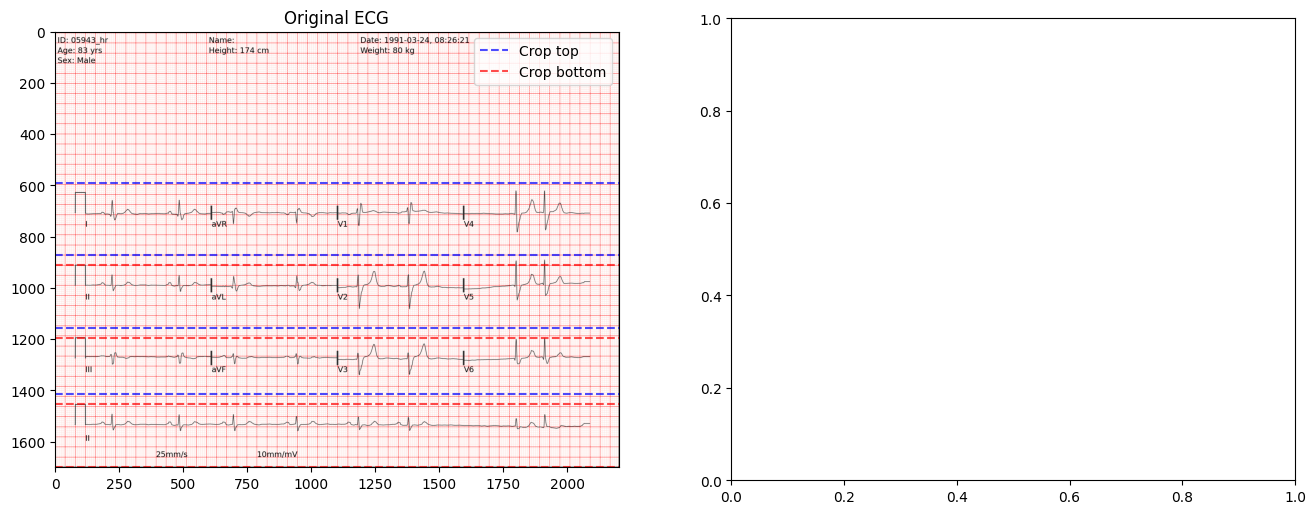

In [8]:

sample_path = os.path.join(path, image_files[0])
img = cv2.imread(sample_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

BLACK_THRESHOLD = 80
CAL_SPIKE_THRESHOLD = 25
LEFT_PCT = 0.10
MIN_INTER_STRIP_GAP = 150
HEADER_GAP_RATIO = 3.0
PADDING = 20

bands, strip_starts = detect_signal_bands(
    img,
    black_threshold=BLACK_THRESHOLD,
    left_pct=LEFT_PCT,
    min_inter_strip_gap=MIN_INTER_STRIP_GAP,
    header_gap_ratio=HEADER_GAP_RATIO,
    padding=PADDING
)
signal_bands = bands

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].imshow(img_rgb)
axes[0].set_title('Original ECG')
for s, e in signal_bands:
    axes[0].axhline(s - PADDING, color='blue', linewidth=1.5, linestyle='--', alpha=0.7)
    axes[0].axhline(e + PADDING, color='red',  linewidth=1.5, linestyle='--', alpha=0.7)
axes[0].legend(['Crop top', 'Crop bottom'], loc='upper right')

axes[1].plot(smoothed, np.arange(len(smoothed)), color='steelblue')
axes[1].axvline(adaptive_threshold, color='orange', linestyle='--',
                label=f'Adaptive threshold ({adaptive_threshold:.2f})')
axes[1].invert_yaxis()
axes[1].set_xlabel('Smoothed black pixel count')
axes[1].set_ylabel('Row index')
axes[1].set_title('Row Projection Profile')
axes[1].legend()

plt.tight_layout()
plt.show()

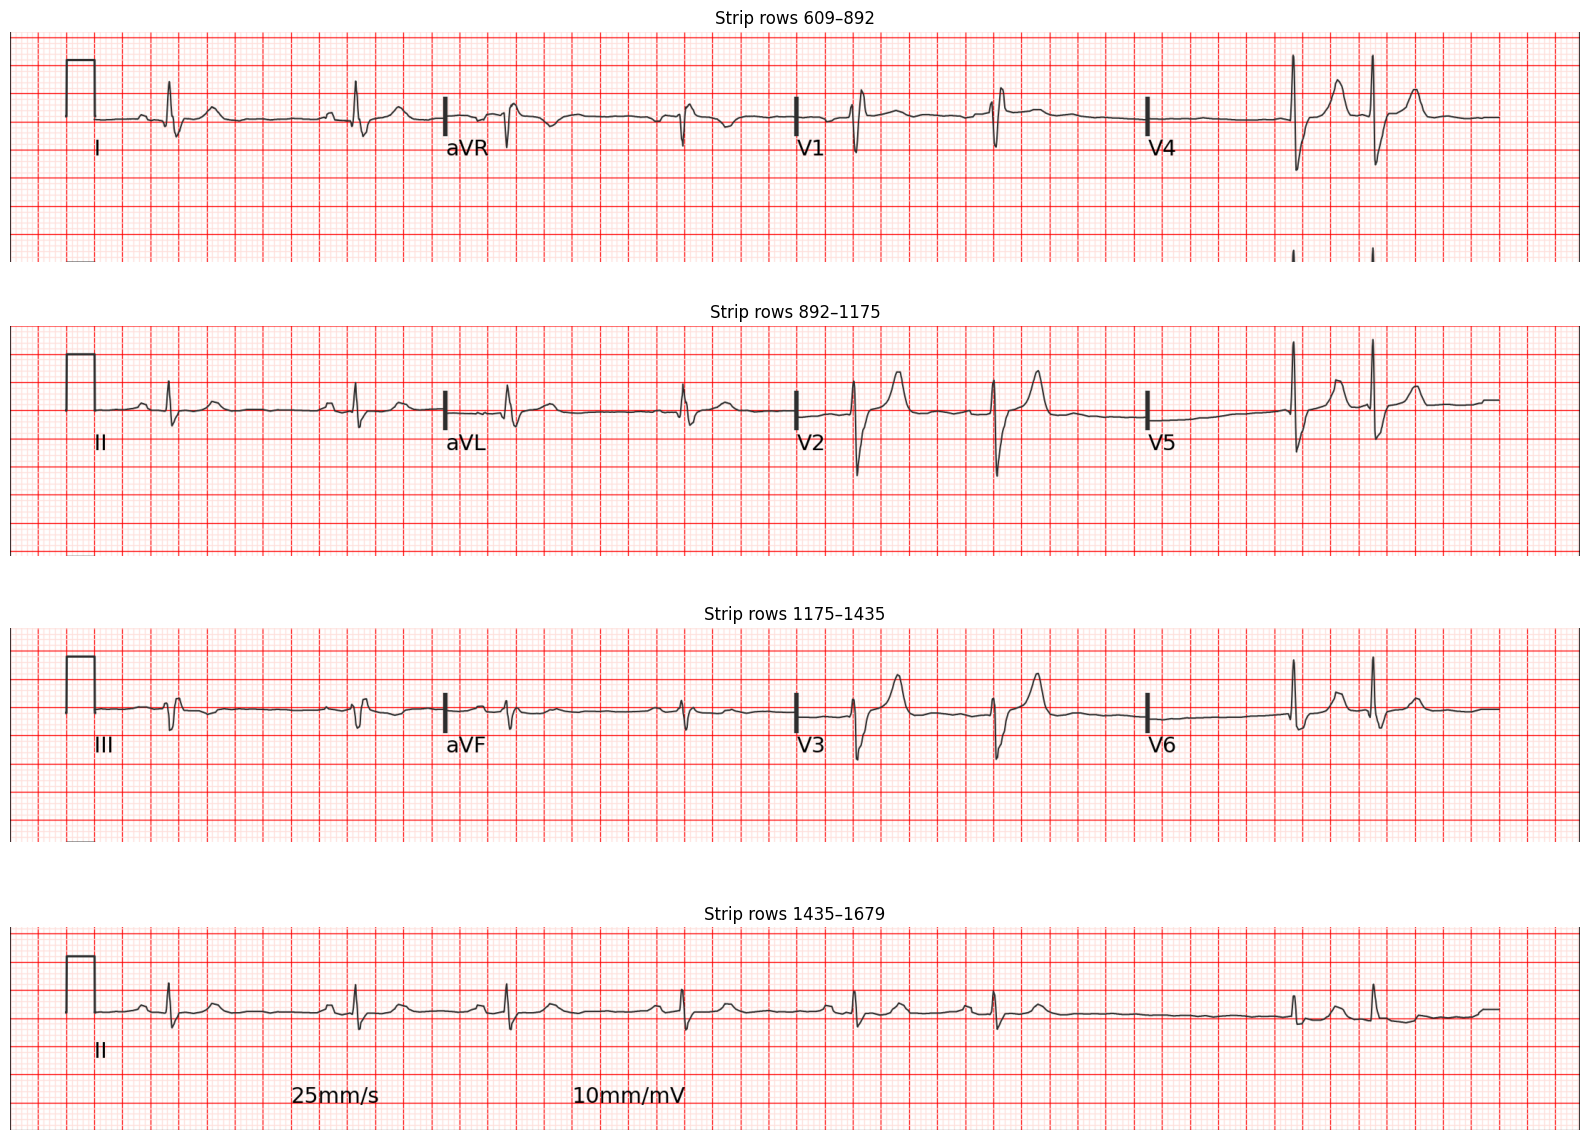

In [9]:
height = img.shape[0]
fig, axes = plt.subplots(len(signal_bands), 1, figsize=(16, 3 * len(signal_bands)))
if len(signal_bands) == 1:
    axes = [axes]

for ax, (s, e) in zip(axes, signal_bands):
    y1 = max(0, s - PADDING)
    y2 = min(height, e + PADDING)
    ax.imshow(img_rgb[y1:y2, :])
    ax.set_title(f'Strip rows {s}–{e}')
    ax.axis('off')

plt.tight_layout()
plt.show()

In [10]:
BLACK_THRESHOLD = 80
CAL_SPIKE_THRESHOLD = 25
LEFT_PCT = 0.10
MIN_INTER_STRIP_GAP = 150
HEADER_GAP_RATIO = 3.0
PADDING = 20

output_base = os.path.join(path, '..', 'Strips')
output_base = os.path.abspath(output_base)


all_results = {}
errors = []

for fname in image_files:
    img_path = os.path.join(path, fname)
    try:
        saved = split_ecg_strips(
            image_path=img_path,
            output_dir=output_base,
            black_threshold=BLACK_THRESHOLD,
            cal_spike_threshold=CAL_SPIKE_THRESHOLD,
            left_pct=LEFT_PCT,
            min_inter_strip_gap=MIN_INTER_STRIP_GAP,
            header_gap_ratio=HEADER_GAP_RATIO,
            padding=PADDING
        )
        all_results[fname] = saved
        n = len(saved)
    except Exception as ex:
        errors.append((fname, str(ex)))
        print(f'✗ {fname}  ERROR: {ex}')


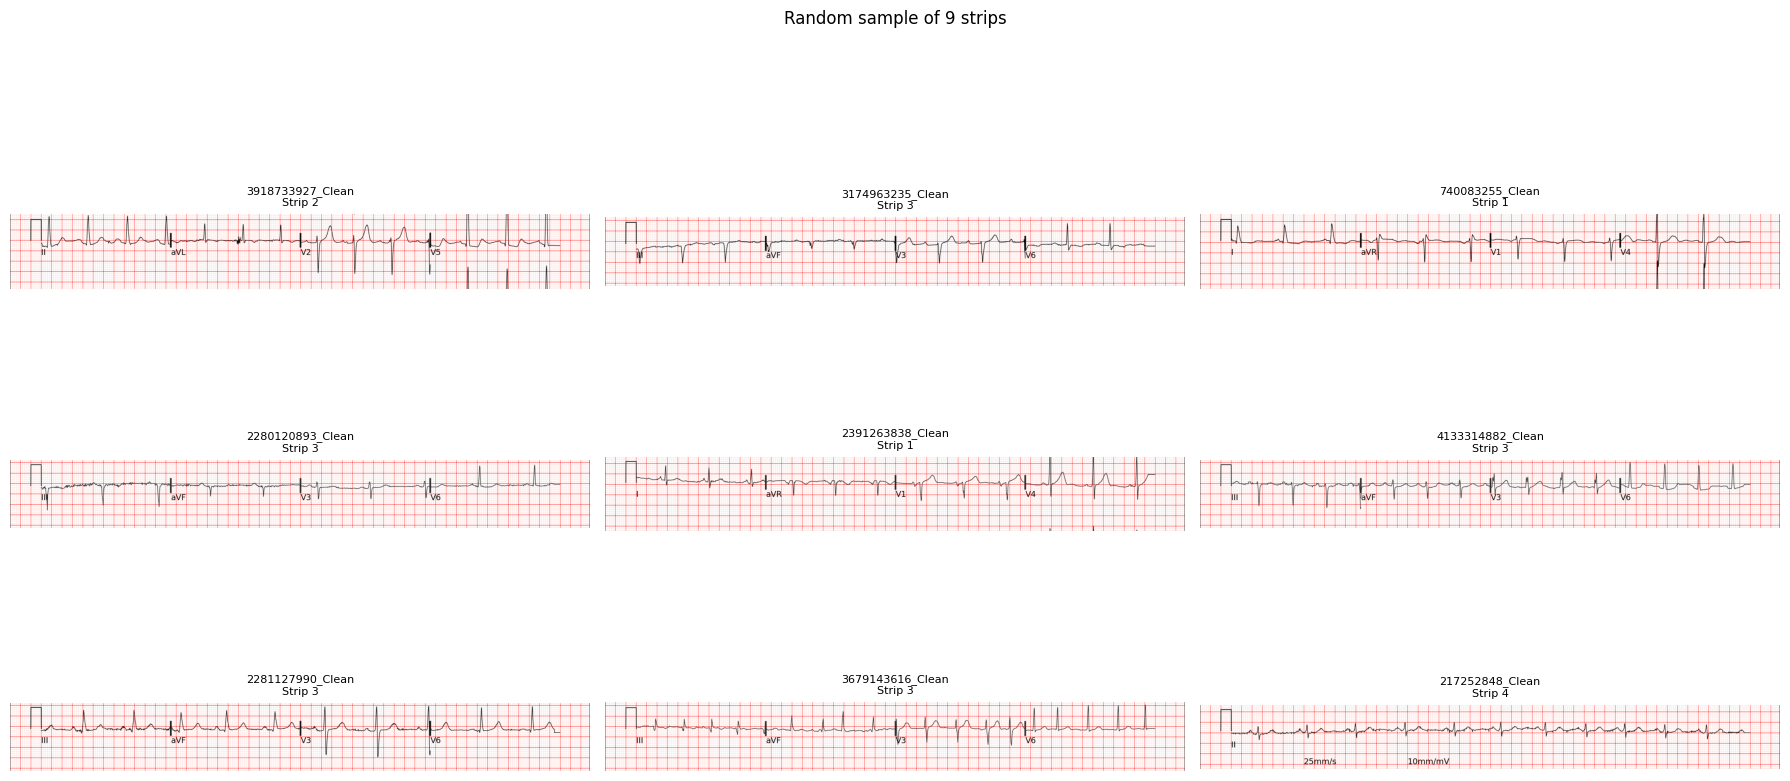

In [11]:
import random
from PIL import Image

def show_random_strips(all_results, n=9, cols=3):

    # Flatten sample strips
    all_strips = [strip for strips in all_results.values() for strip in strips]
    sample = random.sample(all_strips, min(n, len(all_strips)))

    rows = int(np.ceil(len(sample) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 3))
    axes = np.array(axes).flatten()

    for ax, strip_path in zip(axes, sample):
        img = Image.open(strip_path)
        ax.imshow(img)
        parts = os.path.basename(strip_path).replace('.png', '').split('_strip_')
        title = f"{parts[0]}\nStrip {parts[1]}" if len(parts) == 2 else os.path.basename(strip_path)
        ax.set_title(title, fontsize=8)
        ax.axis('off')

    for ax in axes[len(sample):]:
        ax.axis('off')

    plt.suptitle(f'Random sample of {len(sample)} strips', fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()

show_random_strips(all_results, n=9, cols=3)

ANNA: Splitting the strips into different signals

In [56]:
def detect_signals_in_strips(img, black_threshold=80, col_spike_threshold=50, min_consecutive = 5):
    """
    The goal of this function is to determine the signals within each of the bands.
    We do this using the black bands that separate the signals
    """
    h, w = img.shape[:2]

    # Cut square wave
    b, g, r = cv2.split(img)
    black_mask = (r < black_threshold) & (g < black_threshold) & (b < black_threshold)
    #Get sums of each column
    col_sums = black_mask.sum(axis=0).astype(float)
    spike_cols = np.where(col_sums > col_spike_threshold)[0]


    # Identify chunks of consecutive columns
    chunks = []
    if len(spike_cols) > 0:
        index = 0
        chunk_start = spike_cols[index]
        chunk = [chunk_start]
        chunk_length = 1
        while index < len(spike_cols) - 1:
            if spike_cols[index + 1] == spike_cols[index] + 1:
                chunk.append(spike_cols[index + 1])
                chunk_length += 1
            else:
                if chunk_length >= min_consecutive:
                    chunks.append(chunk)
                chunk_start = spike_cols[index + 1]
                chunk = [chunk_start]
                chunk_length = 1
            index += 1
        if chunk_length >= min_consecutive:
            chunks.append(chunk)
        
    #turn chunks into split points
    split_points = [chunk[len(chunk)//2] for chunk in chunks]
    split_points.append(w)
    split_points = [0] + split_points
    return split_points




In [59]:
def split_strips_into_signals(strip_path, output_dir, black_threshold=80, col_spike_threshold=50, min_consecutive = 5):

    img = cv2.imread(str(strip_path))
    if img is None:
        raise ValueError(f'Could not read image: {strip_path}')

    h, w = img.shape[:2]
    split_points = detect_signals_in_strips(img, black_threshold, col_spike_threshold, min_consecutive)

    os.makedirs(output_dir, exist_ok=True)
    stem = Path(strip_path).stem
    saved = []

    for i in range(len(split_points) - 1):
        crop = img[:, split_points[i]:split_points[i+1]]
        out_path = os.path.join(output_dir, f'{stem}_chunk_{i+1}.png')
        cv2.imwrite(out_path, crop)
        saved.append(out_path)

    return saved

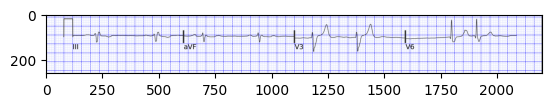

In [41]:
test_strip_path = all_results['3080195423_Clean.png'][2]
test_strip_img = cv2.imread(test_strip_path)
plt.imshow(test_strip_img)

In [57]:
detect_signals_in_strips(test_strip_img)

[0, np.int64(610), np.int64(1102), np.int64(1594), 2200]

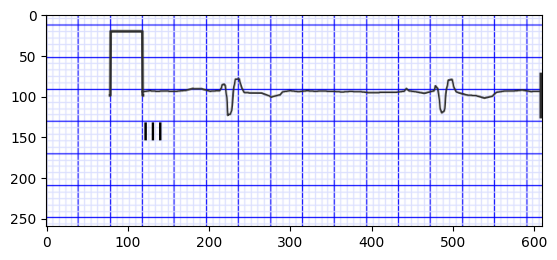

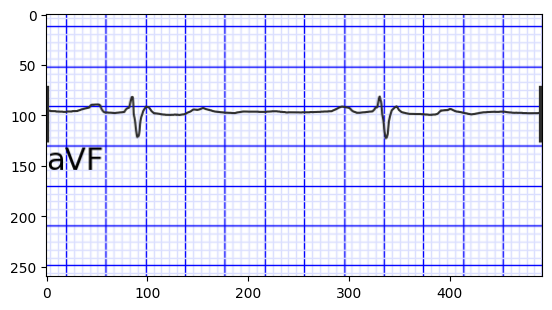

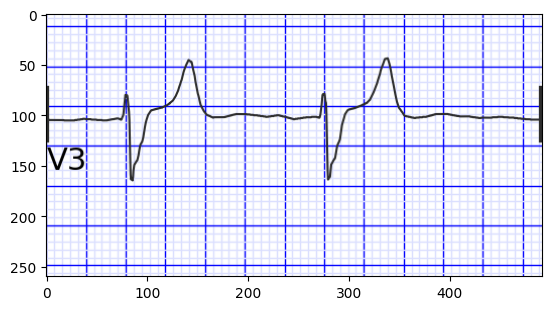

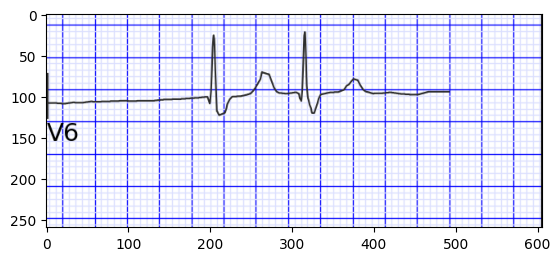

In [60]:
test_paths = split_strips_into_signals(test_strip_path,"test/")
for path in test_paths:
    test_img = cv2.imread(path)
    plt.imshow(test_img)
    plt.show()
